# Importing Required Libraries

This cell imports all Python libraries needed for data analysis, model training, and visualization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
np.random.seed(42)
n_samples = 768

# Generating Synthetic Data Features

This cell randomly generates features such as `Pregnancies`, `Glucose`, `BloodPressure`, etc., to form the dataset.

In [ ]:
pregnancies = np.random.randint(0, 17, size=n_samples)
glucose = np.random.randint(40, 200, size=n_samples)
blood_pressure = np.random.randint(40, 122, size=n_samples)
skin_thickness = np.random.randint(0, 99, size=n_samples)
insulin = np.random.randint(0, 846, size=n_samples)
bmi = np.random.uniform(18.2, 67.1, size=n_samples)
diabetes_pedigree = np.random.uniform(0.08, 2.42, size=n_samples)
age = np.random.randint(21, 81, size=n_samples)

# Generating Synthetic Data Features

This cell randomly generates features such as `Pregnancies`, `Glucose`, `BloodPressure`, etc., to form the dataset.

In [ ]:
logit = (0.05 * pregnancies + 0.02 * glucose + 0.005 * blood_pressure +
         0.002 * insulin + 0.1 * bmi + 0.8 * diabetes_pedigree + 0.01 * age - 10.5)
prob = 1 / (1 + np.exp(-logit))
outcome = np.random.binomial(1, prob)

# Creating a DataFrame from Synthetic Data

This cell combines all the features and the resulting `Outcome` into a single pandas DataFrame.

In [ ]:
df = pd.DataFrame({
    'Pregnancies': pregnancies, 'Glucose': glucose, 'BloodPressure': blood_pressure,
    'SkinThickness': skin_thickness, 'Insulin': insulin, 'BMI': bmi,
    'DiabetesPedigreeFunction': diabetes_pedigree, 'Age': age, 'Outcome': outcome
})

# Save Data to CSV File

This cell stores the DataFrame that was created into the file `diabetes.csv`.

In [ ]:
df.to_csv('diabetes.csv', index=False)

# Split Training and Test Data

This cell divides the dataset into a training set (`X_train`, `y_train`) and a test set (`X_test`, `y_test`) for model evaluation.

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Perform Feature Scaling

This cell uses the `StandardScaler` to standardize the features of the training and testing data.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the SVM Model

This cell trains a Support Vector Machine (SVM) model using the scaled training data.

In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=2,
    gamma=0.1,
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(C=2, gamma=0.1, probability=True, random_state=42)

# Calculating Probabilities and ROC Curve Components

This cell predicts class probabilities and calculates the False Positive Rate (FPR) and True Positive Rate (TPR) for the ROC curve.

In [ ]:
y_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculating AUC Manually (Trapezoidal Rule)

This cell calculates the Area Under the Curve (AUC) manually using the trapezoidal integration method.

In [ ]:
auc_trapezoidal = 0.0
for i in range(1, len(fpr)):
    delta_x = fpr[i] - fpr[i-1]
    mean_y = (tpr[i] + tpr[i-1]) / 2.0
    auc_trapezoidal += mean_y * delta_x

# Displays the AUC Score

This cell compares and displays the results of the manual AUC calculation with the AUC calculated using the `auc` function from scikit-learn.

In [ ]:
from sklearn.metrics import roc_auc_score

auc_sklearn = auc(fpr, tpr)
auc_roc_score = roc_auc_score(y_test, y_probs)

print(f"Hasil Perhitungan Integral Numerik (Trapesium): {auc_trapezoidal:.6f}")
print(f"Hasil Perhitungan Sklearn AUC Function        : {auc_sklearn:.6f}")
print(f"Hasil ROC AUC Score                           : {auc_roc_score:.6f}")
print(f"Selisih Manual dan Sklearn                    : {abs(auc_trapezoidal - auc_sklearn):.10f}")

Hasil Perhitungan Integral Numerik (Trapesium): 0.878103
Hasil Perhitungan Sklearn AUC Function        : 0.878103
Hasil ROC AUC Score                           : 0.878103
Selisih Manual dan Sklearn                    : 0.0000000000


# Visualizing ROC Curves

This cell creates and saves a Receiver Operating Characteristic (ROC) curve plot to evaluate model performance.

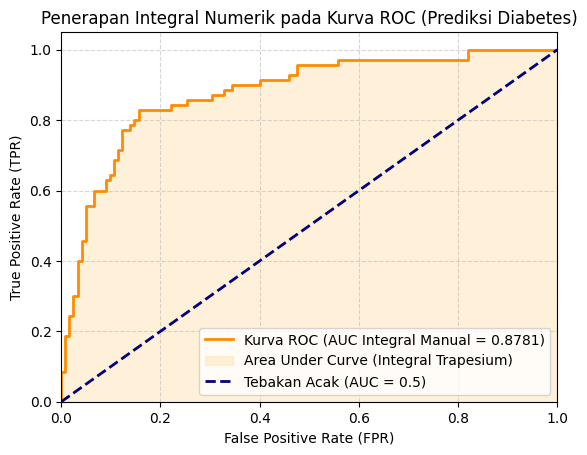

In [ ]:
plt.clf()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Kurva ROC (AUC Integral Manual = {auc_trapezoidal:.4f})')
plt.fill_between(fpr, tpr, color='moccasin', alpha=0.5, label='Area Under Curve (Integral Trapesium)')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Tebakan Acak (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Penerapan Integral Numerik pada Kurva ROC (Prediksi Diabetes)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('roc_curve_auc_final.png', dpi=300, bbox_inches='tight')

# Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Akurasi : {accuracy:.4f}")
print(f"Presisi : {precision:.4f}")
print(f"Recall  : {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi : 0.8229
Presisi : 0.7727
Recall  : 0.7286
F1-Score: 0.7500

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       122
           1       0.77      0.73      0.75        70

    accuracy                           0.82       192
   macro avg       0.81      0.80      0.81       192
weighted avg       0.82      0.82      0.82       192



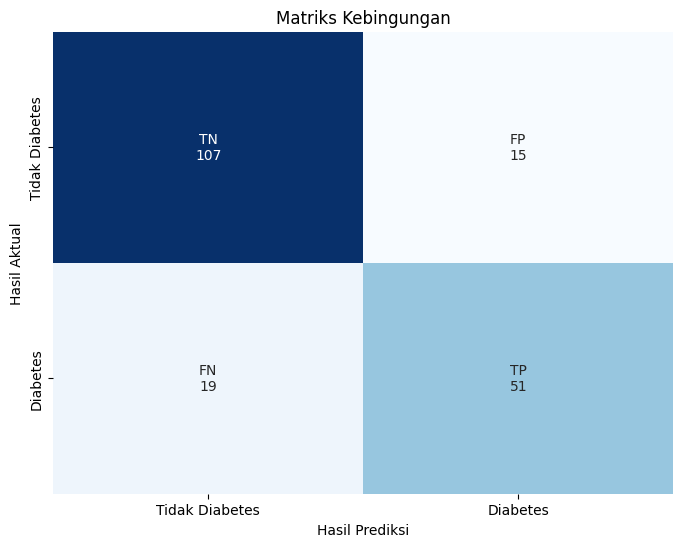

In [ ]:
cm = confusion_matrix(y_test, y_pred)

labels = np.asarray([['TN\n{0}'.format(cm[0,0]), 'FP\n{0}'.format(cm[0,1])],
                     ['FN\n{0}'.format(cm[1,0]), 'TP\n{0}'.format(cm[1,1])]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
plt.xlabel('Hasil Prediksi')
plt.ylabel('Hasil Aktual')
plt.title('Matriks Kebingungan')
plt.show()